In [1]:
import os
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

c:\Users\mg050\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download(
    "hassankhaled21/egyptian-real-estate-listings"
)

print("Dataset downloaded successfully!")
print(path)

Dataset downloaded successfully!
C:\Users\mg050\.cache\kagglehub\datasets\hassankhaled21\egyptian-real-estate-listings\versions\1


In [3]:
csv_file_path = ""

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file_path = os.path.join(root, file)
            break

print("CSV file found:")
print(csv_file_path)

CSV file found:
C:\Users\mg050\.cache\kagglehub\datasets\hassankhaled21\egyptian-real-estate-listings\versions\1\egypt_real_estate_listings.csv


In [4]:
df = pd.read_csv(csv_file_path)

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


In [5]:
df.shape

(19924, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             19924 non-null  str  
 1   price           19385 non-null  str  
 2   description     19846 non-null  str  
 3   location        19833 non-null  str  
 4   type            19847 non-null  str  
 5   size            19847 non-null  str  
 6   bedrooms        19780 non-null  str  
 7   bathrooms       19784 non-null  str  
 8   available_from  19261 non-null  str  
 9   payment_method  19383 non-null  str  
 10  down_payment    5445 non-null   str  
dtypes: str(11)
memory usage: 1.7 MB


In [7]:
df.isnull().sum()

url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           140
available_from      663
payment_method      541
down_payment      14479
dtype: int64

In [8]:
df.isnull().mean() * 100

url                0.000000
price              2.705280
description        0.391488
location           0.456736
type               0.386469
size               0.386469
bedrooms           0.722746
bathrooms          0.702670
available_from     3.327645
payment_method     2.715318
down_payment      72.671150
dtype: float64

In [9]:
df["type"].value_counts()

type
Apartment          8355
Chalet             4038
Villa              3570
Townhouse          1335
Twin House          834
Duplex              622
Penthouse           569
iVilla              268
Hotel Apartment     104
Land                 63
Cabin                38
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Bulk Sale Unit        3
Bungalow              1
Name: count, dtype: int64

In [10]:
df["type"].nunique()

17

In [11]:
df["type"].value_counts(normalize=True) * 100

type
Apartment          42.097042
Chalet             20.345644
Villa              17.987605
Townhouse           6.726457
Twin House          4.202146
Duplex              3.133975
Penthouse           2.866932
iVilla              1.350330
Hotel Apartment     0.524009
Land                0.317428
Cabin               0.191465
Palace              0.115887
Whole Building      0.070540
Roof                0.030231
Full Floor          0.020154
Bulk Sale Unit      0.015116
Bungalow            0.005039
Name: proportion, dtype: float64

In [12]:
df["payment_method"].value_counts()

payment_method
Cash            15521
Installments     3862
Name: count, dtype: int64

In [13]:
df["payment_method"].value_counts(normalize=True) * 100

payment_method
Cash            80.075324
Installments    19.924676
Name: proportion, dtype: float64

In [14]:
df["price"].head(10)

0     8,000,000
1    25,000,000
2    15,135,000
3    12,652,000
4    45,250,000
5    19,760,000
6     9,000,000
7     2,770,000
8    13,200,000
9    22,300,000
Name: price, dtype: str

In [15]:
df["price_clean"] = df["price"].str.replace(",", "", regex=False)
df[["price", "price_clean"]].head(10)

,price,price_clean
0,"8,000,000",8000000
1,"25,000,000",25000000
2,"15,135,000",15135000
3,"12,652,000",12652000
4,"45,250,000",45250000
5,"19,760,000",19760000
6,"9,000,000",9000000
7,"2,770,000",2770000
8,"13,200,000",13200000
9,"22,300,000",22300000


In [16]:
df["price_clean"] = pd.to_numeric(df["price_clean"], errors="coerce")

df["price_clean"].dtype

dtype('float64')

In [17]:
df["price_clean"].describe()

count    1.938500e+04
mean     1.641531e+07
std      2.369791e+07
min      1.869000e+05
25%      6.000000e+06
50%      1.034555e+07
75%      1.816900e+07
max      8.400000e+08
Name: price_clean, dtype: float64

In [18]:
df["price_clean"].nlargest(10)

14762    840000000.0
12670    650000000.0
18560    453000000.0
12051    400000000.0
13447    400000000.0
15066    400000000.0
9871     375000000.0
13068    375000000.0
12370    374000000.0
11523    360000000.0
Name: price_clean, dtype: float64

In [19]:
df.loc[df["price_clean"].idxmax(), ["price", "type", "size", "bedrooms", "bathrooms", "location"]]

price                                    840,000,000
type                                           Villa
size                         11,840 sqft / 1,100 sqm
bedrooms                                     5+ Maid
bathrooms                                          6
location     Marassi, Sidi Abdel Rahman, North Coast
Name: 14762, dtype: str

In [20]:
Q1 = df["price_clean"].quantile(0.25)
Q3 = df["price_clean"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Bound:", upper_bound)

Q1: 6000000.0
Q3: 18169000.0
IQR: 12169000.0
Upper Bound: 36422500.0


In [21]:
(df["price_clean"] > upper_bound).sum()

np.int64(1556)

In [22]:
df.loc[
    df["price_clean"] > upper_bound,
    ["price_clean", "type", "size", "bedrooms", "bathrooms", "location"]
].head(10)

,price_clean,type,size,bedrooms,bathrooms,location
4,45250000.0,Villa,"4,306 sqft / 400 sqm",7,7,"Granville, New Capital City, Cairo"
35,71500000.0,Villa,"4,338 sqft / 403 sqm",7+ Maid,5,"Belle Vie, New Zayed City, Sheikh Zayed City, ..."
64,39200000.0,Villa,"3,240 sqft / 301 sqm",4+ Maid,4,"Ogami, Ras Al Hekma, North Coast"
83,60000000.0,Villa,"8,611 sqft / 800 sqm",4+ Maid,4,"Soul North Coast, Qesm Ad Dabaah, North Coast"
85,60000000.0,Villa,"7,212 sqft / 670 sqm",5+ Maid,5,"Ramla Lakeside, Qesm Ad Dabaah, North Coast"
87,55000000.0,Villa,"4,176 sqft / 388 sqm",5,5,"Swan Lake Residence, 5th Settlement Compounds,..."
102,43000000.0,Villa,"2,691 sqft / 250 sqm",3+ Maid,4,"June, Ras Al Hekma, North Coast"
125,40000000.0,Villa,"4,155 sqft / 386 sqm",6+ Maid,7,"City Gate, 5th Settlement Compounds, The 5th S..."
126,52713262.0,Villa,"3,757 sqft / 349 sqm",5+ Maid,6,"Marassi, Sidi Abdel Rahman, North Coast"
167,39000000.0,Villa,"3,014 sqft / 280 sqm",4+ Maid,5,"Marsa Baghush, Qesm Marsa Matrouh, North Coast"


In [23]:
df["size"].head(10)

0       732 sqft / 68 sqm
1    2,368 sqft / 220 sqm
2    1,270 sqft / 118 sqm
3    1,787 sqft / 166 sqm
4    4,306 sqft / 400 sqm
5    1,356 sqft / 126 sqm
6    2,820 sqft / 262 sqm
7    3,983 sqft / 370 sqm
8    2,368 sqft / 220 sqm
9    2,099 sqft / 195 sqm
Name: size, dtype: str

In [24]:
df["size_sqm"] = (
    df["size"]
    .str.extract(r"([\d,]+\.?\d*)\s*sqm", expand=False)
    .str.replace(",", "", regex=False)
)

df["size_sqm"] = pd.to_numeric(df["size_sqm"], errors="coerce")

df[["size", "size_sqm"]].head(10)

,size,size_sqm
0,732 sqft / 68 sqm,68.0
1,"2,368 sqft / 220 sqm",220.0
2,"1,270 sqft / 118 sqm",118.0
3,"1,787 sqft / 166 sqm",166.0
4,"4,306 sqft / 400 sqm",400.0
5,"1,356 sqft / 126 sqm",126.0
6,"2,820 sqft / 262 sqm",262.0
7,"3,983 sqft / 370 sqm",370.0
8,"2,368 sqft / 220 sqm",220.0
9,"2,099 sqft / 195 sqm",195.0


In [25]:
df["size_sqm"].describe()

count    1.984700e+04
mean     1.034563e+03
std      1.122570e+05
min      1.000000e+00
25%      1.270000e+02
50%      1.700000e+02
75%      2.410000e+02
max      1.581169e+07
Name: size_sqm, dtype: float64

In [26]:
df["size_sqm"].nlargest(10)

4410     15811692.0
8277       302400.0
15510       96106.0
794         27500.0
15204       21000.0
9669         9500.0
18512        8400.0
8174         6779.0
13451        4200.0
12670        3800.0
Name: size_sqm, dtype: float64

In [27]:
df.loc[
    df["size_sqm"].idxmax(),
    ["size", "price", "type", "bedrooms", "bathrooms", "location"]
]

size                         170,195,636 sqft / 15,811,692 sqm
price                                               11,692,311
type                                                 Apartment
bedrooms                                                     3
bathrooms                                                    3
location     Sarai, Mostakbal City Compounds, Mostakbal Cit...
Name: 4410, dtype: str

In [28]:
id="n2k8wf"
(df["size_sqm"] > 10000).sum()

np.int64(5)

In [29]:
df.loc[
    df["size_sqm"] > 10000,
    ["size", "price", "type", "bedrooms", "bathrooms", "location"]
]

,size,price,type,bedrooms,bathrooms,location
794,"296,008 sqft / 27,500 sqm","300,000,000",Land,NaN,NaN,"Green Revolution, Sheikh Zayed Compounds, Shei..."
4410,"170,195,636 sqft / 15,811,692 sqm","11,692,311",Apartment,3,3,"Sarai, Mostakbal City Compounds, Mostakbal Cit..."
8277,"3,255,007 sqft / 302,400 sqm",NaN,Land,NaN,NaN,"The 6th Settlement, New Cairo City, Cairo"
15204,"226,042 sqft / 21,000 sqm","130,200,000",Land,NaN,NaN,"New Zayed City, Sheikh Zayed City, Giza"
15510,"1,034,476 sqft / 96,106 sqm","6,550,000",Chalet,2,2,"Mountain View, Ras Al Hekma, North Coast"


In [30]:
df.loc[
    df["size_sqm"] > 10000,
    ["size_sqm", "price_clean", "type", "location"]
].assign(
    price_per_sqm=lambda x: x["price_clean"] / x["size_sqm"]
)

,size_sqm,price_clean,type,location,price_per_sqm
794,27500.0,300000000.0,Land,"Green Revolution, Sheikh Zayed Compounds, Shei...",10909.090909
4410,15811692.0,11692311.0,Apartment,"Sarai, Mostakbal City Compounds, Mostakbal Cit...",0.739472
8277,302400.0,NaN,Land,"The 6th Settlement, New Cairo City, Cairo",NaN
15204,21000.0,130200000.0,Land,"New Zayed City, Sheikh Zayed City, Giza",6200.000000
15510,96106.0,6550000.0,Chalet,"Mountain View, Ras Al Hekma, North Coast",68.153913


In [31]:
df["size_sqm"].nlargest(20)

4410     15811692.0
8277       302400.0
15510       96106.0
794         27500.0
15204       21000.0
9669         9500.0
18512        8400.0
8174         6779.0
13451        4200.0
12670        3800.0
9385         3300.0
13510        3050.0
17140        3000.0
18482        3000.0
9871         2801.0
16617        2450.0
18096        2450.0
14748        2400.0
14305        2350.0
8246         2250.0
Name: size_sqm, dtype: float64

In [32]:
df.loc[15510, ["size", "price", "type", "bedrooms", "bathrooms", "location"]]

size                      1,034,476 sqft / 96,106 sqm
price                                       6,550,000
type                                           Chalet
bedrooms                                            2
bathrooms                                           2
location     Mountain View, Ras Al Hekma, North Coast
Name: 15510, dtype: str

In [33]:
df.loc[
    df["size_sqm"] > 10000,
    ["size_sqm", "type"]
]

,size_sqm,type
794,27500.0,Land
4410,15811692.0,Apartment
8277,302400.0,Land
15204,21000.0,Land
15510,96106.0,Chalet


In [34]:
df.loc[
    (df["size_sqm"] > 10000) & (df["type"] != "Land"),
    "size_sqm"
] = pd.NA

df.loc[[4410, 15510], ["size", "size_sqm", "type"]]

,size,size_sqm,type
4410,"170,195,636 sqft / 15,811,692 sqm",NaN,Apartment
15510,"1,034,476 sqft / 96,106 sqm",NaN,Chalet


In [35]:
df["size_sqm"].describe()

count     19845.000000
mean        233.065105
std        2168.305059
min           1.000000
25%         127.000000
50%         170.000000
75%         241.000000
max      302400.000000
Name: size_sqm, dtype: float64

In [36]:
df["size_sqm"].isna().sum()

np.int64(79)

In [37]:
df["bedrooms"].value_counts().head(20)

bedrooms
3               4959
3+ Maid         3737
2               2849
4+ Maid         2126
2+ Maid         1748
4               1126
5+ Maid          786
1                751
1+ Maid          447
5                325
studio           280
6+ Maid          254
7+ Maid          128
6                 93
7++ Maid          67
studio+ Maid      48
7                 33
7+                23
Name: count, dtype: int64

In [38]:
df["bedrooms"].dropna().unique()

<StringArray>
[     '1+ Maid',            '4',            '2',            '3',
            '7',      '5+ Maid',      '3+ Maid',      '2+ Maid',
            '1',      '4+ Maid',      '7+ Maid',       'studio',
            '5',      '6+ Maid', 'studio+ Maid',     '7++ Maid',
           '7+',            '6']
Length: 18, dtype: str

In [39]:
df["bedrooms_num"] = (
    df["bedrooms"]
    .str.extract(r"(\d+)", expand=False)
)

df["bedrooms_num"] = pd.to_numeric(
    df["bedrooms_num"],
    errors="coerce"
)

df[["bedrooms", "bedrooms_num"]].head(20)

,bedrooms,bedrooms_num
0,1+ Maid,1.0
1,4,4.0
2,2,2.0
3,3,3.0
4,7,7.0
5,3,3.0
6,4,4.0
7,5+ Maid,5.0
8,3,3.0
9,3+ Maid,3.0


In [40]:
df["bedrooms"].str.contains("studio", case=False, na=False).sum()

np.int64(328)

In [41]:
df["bedrooms_num"].isna().sum()

np.int64(472)

In [42]:
df["bedrooms_num"].value_counts().sort_index()

bedrooms_num
1.0    1198
2.0    4597
3.0    8696
4.0    3252
5.0    1111
6.0     347
7.0     251
Name: count, dtype: int64

In [43]:
df["bathrooms"].value_counts().head(20)

bathrooms
3       6562
2       5529
4       3281
1       2097
5       1313
6        463
7        223
7+       159
2.0       48
3.0       48
1.0       21
4.0       19
5.0       11
none       5
6.0        3
7.0        2
Name: count, dtype: int64

In [44]:
df["bathrooms_num"] = (
    df["bathrooms"]
    .str.extract(r"(\d+)", expand=False)
)

df["bathrooms_num"] = pd.to_numeric(
    df["bathrooms_num"],
    errors="coerce"
)

df[["bathrooms", "bathrooms_num"]].head(20)

,bathrooms,bathrooms_num
0,1,1.0
1,4,4.0
2,2,2.0
3,2,2.0
4,7,7.0
5,2,2.0
6,5,5.0
7,5,5.0
8,3,3.0
9,2,2.0


In [45]:
df["bathrooms_num"].value_counts().sort_index()

bathrooms_num
1.0    2118
2.0    5577
3.0    6610
4.0    3300
5.0    1324
6.0     466
7.0     384
Name: count, dtype: int64

In [46]:
df["available_from"].head(20)

0     31 Aug 2025
1      2 Sep 2025
2     19 Aug 2025
3     26 Aug 2025
4      2 Sep 2025
5     26 Aug 2025
6      3 Jul 2025
7     26 Aug 2025
8     25 Aug 2025
9      7 Aug 2025
10            NaN
11    31 Aug 2025
12    17 Jul 2025
13     2 Sep 2025
14    30 Aug 2025
15     1 Sep 2025
16    31 Aug 2025
17     1 Sep 2025
18     2 Sep 2025
19    31 Aug 2025
Name: available_from, dtype: str

In [47]:
df["available_from_dt"] = pd.to_datetime(
    df["available_from"],
    errors="coerce"
)

df[["available_from", "available_from_dt"]].head(20)

,available_from,available_from_dt
0,31 Aug 2025,2025-08-31
1,2 Sep 2025,2025-09-02
2,19 Aug 2025,2025-08-19
3,26 Aug 2025,2025-08-26
4,2 Sep 2025,2025-09-02
5,26 Aug 2025,2025-08-26
6,3 Jul 2025,2025-07-03
7,26 Aug 2025,2025-08-26
8,25 Aug 2025,2025-08-25
9,7 Aug 2025,2025-08-07


In [48]:
df["available_from_dt"].min(), df["available_from_dt"].max()

(Timestamp('2023-06-14 00:00:00'), Timestamp('2027-10-31 00:00:00'))

In [49]:
df["available_from_dt"].dt.year.value_counts().sort_index()

available_from_dt
2023.0        5
2024.0       93
2025.0    18975
2026.0      187
2027.0        1
Name: count, dtype: int64

In [50]:
df.loc[
    df["available_from_dt"].dt.year == 2027,
    ["available_from", "price", "type", "size", "bedrooms", "bathrooms", "location"]
]

,available_from,price,type,size,bedrooms,bathrooms,location
414,31 Oct 2027,"5,000,000",Apartment,969 sqft / 90 sqm,2,1,"Al Thawra El Khadra, 26th of July Corridor, 6 ..."


In [51]:
df["available_from_dt"].isna().sum()

np.int64(663)

In [52]:
df["down_payment"].head(20)

0      1,200,000 EGP
1      2,100,000 EGP
2      1,513,000 EGP
3      1,260,000 EGP
4      2,262,500 EGP
5        988,000 EGP
6                NaN
7                NaN
8                NaN
9      2,230,000 EGP
10               NaN
11               NaN
12       900,000 EGP
13               NaN
14     1,002,330 EGP
15     5,000,000 EGP
16               NaN
17    11,724,000 EGP
18       353,175 EGP
19       100,000 EGP
Name: down_payment, dtype: str

In [53]:
df["down_payment_clean"] = (
    df["down_payment"]
    .str.replace(",", "", regex=False)
    .str.replace(" EGP", "", regex=False)
)

df["down_payment_clean"] = pd.to_numeric(
    df["down_payment_clean"],
    errors="coerce"
)

df[["down_payment", "down_payment_clean"]].head(20)

,down_payment,down_payment_clean
0,"1,200,000 EGP",1200000.0
1,"2,100,000 EGP",2100000.0
2,"1,513,000 EGP",1513000.0
3,"1,260,000 EGP",1260000.0
4,"2,262,500 EGP",2262500.0
5,"988,000 EGP",988000.0
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,"2,230,000 EGP",2230000.0


In [54]:
df["down_payment_clean"].describe()

count    5.445000e+03
mean     1.981042e+06
std      3.868577e+06
min      1.000000e+00
25%      4.837500e+05
50%      9.430000e+05
75%      2.040000e+06
max      1.500000e+08
Name: down_payment_clean, dtype: float64

In [55]:
df["down_payment_clean"].sort_values(ascending=False).head(10)

794     150000000.0
2163     68000000.0
2110     43103691.0
1756     43000000.0
276      42000000.0
6679     40000000.0
1639     40000000.0
1844     39009000.0
7416     33905700.0
2971     33892759.0
Name: down_payment_clean, dtype: float64

In [56]:
df.loc[
    df["down_payment_clean"].nlargest(10).index,
    ["price_clean", "down_payment_clean", "type", "size_sqm", "location"]
]

,price_clean,down_payment_clean,type,size_sqm,location
794,300000000.0,150000000.0,Land,27500.0,"Green Revolution, Sheikh Zayed Compounds, Shei..."
2163,136000000.0,68000000.0,Villa,554.0,"Eden, Cairo Gate, Sheikh Zayed Compounds, Shei..."
2110,143678971.0,43103691.0,Villa,456.0,"Mangroovy Residence, Al Gouna, Hurghada, Red Sea"
1756,158000000.0,43000000.0,Villa,754.0,"City Gate, 5th Settlement Compounds, The 5th S..."
276,140000000.0,42000000.0,Villa,455.0,"Mangroovy Residence, Al Gouna, Hurghada, Red Sea"
1639,96000000.0,40000000.0,Villa,530.0,"Marassi, Sidi Abdel Rahman, North Coast"
6679,96000000.0,40000000.0,Villa,530.0,"Soul North Coast, Qesm Ad Dabaah, North Coast"
1844,88470000.0,39009000.0,Villa,344.0,"Soul North Coast, Qesm Ad Dabaah, North Coast"
7416,80000000.0,33905700.0,Villa,612.0,"City Gate, 5th Settlement Compounds, The 5th S..."
2971,338927597.0,33892759.0,Palace,1879.0,"Katameya Dunes, El Katameya Compounds, El Kata..."


In [57]:
df["down_payment_ratio"] = (
    df["down_payment_clean"] / df["price_clean"]
)

df["down_payment_ratio"].describe()

count    5.445000e+03
mean     1.421032e-01
std      1.374576e-01
min      1.219512e-08
25%      5.000000e-02
50%      9.999997e-02
75%      2.000000e-01
max      5.000000e-01
Name: down_payment_ratio, dtype: float64

In [58]:
df["description"].head(10)

0    OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...
1    For sale, a villa with immediate delivery in C...
2    With a down payment of EGP 1,513,000, a fully ...
3    Own an apartment in New Cairo with a minimal d...
4    Project: Granville\nLocation: Fifth Settlement...
5    Chalet with Marina and Lake View in The Island...
6    Penthouse 4BR for sale with Installments over ...
7    Stand-alone villa in NYOUM Compound, October\n...
8    **La Vista Ras El Hikma seaview twinhouse - Re...
9    A 195-square-meter duplex + a 42-square-meter ...
Name: description, dtype: str

In [59]:
df["description"].str.len().describe()

count    19846.000000
mean       925.251537
std        466.289747
min         11.000000
25%        554.000000
50%        864.000000
75%       1213.000000
max       2000.000000
Name: description, dtype: float64

In [60]:
df["location"].head(10)

0         Swan Lake Gouna, Al Gouna, Hurghada, Red Sea
1     Karmell, New Zayed City, Sheikh Zayed City, Giza
2                Azha North, Ras Al Hekma, North Coast
3    Taj City, 5th Settlement Compounds, The 5th Se...
4                   Granville, New Capital City, Cairo
5            Marina 5, Marina, Al Alamein, North Coast
6    The Icon Residence, 5th Settlement Compounds, ...
7    Nyoum October, Northern Expansions, 6 October ...
8     La vista Ras El Hikma, Ras Al Hekma, North Coast
9    Azad, 5th Settlement Compounds, The 5th Settle...
Name: location, dtype: str

In [61]:
df["location"].nunique()

1535

In [62]:
df["location"].value_counts().head(15)

location
Marassi, Sidi Abdel Rahman, North Coast                                                         433
Mountain View iCity, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo        393
Madinaty, Cairo                                                                                 368
Hyde Park, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                  359
Palm Hills New Cairo, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo       322
Silver Sands, Qesm Marsa Matrouh, North Coast                                                   299
O West, 6 October Compounds, 6 October City, Giza                                               283
Sarai, Mostakbal City Compounds, Mostakbal City - Future City, Cairo                            267
Mountain View iCity October, 6 October Compounds, 6 October City, Giza                          257
Mivida, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                

In [63]:
df["location"].isna().sum()

np.int64(91)

In [64]:
df[["price", "price_clean"]].isna().sum()

price          539
price_clean    539
dtype: int64

In [65]:
df[["size", "size_sqm"]].isna().sum()

size        77
size_sqm    79
dtype: int64

In [66]:
df[["bedrooms", "bedrooms_num"]].isna().sum()

bedrooms        144
bedrooms_num    472
dtype: int64

In [67]:
df[["bathrooms", "bathrooms_num"]].isna().sum()

bathrooms        140
bathrooms_num    145
dtype: int64

In [68]:
df[["available_from", "available_from_dt"]].isna().sum()

available_from       663
available_from_dt    663
dtype: int64

In [69]:
df[["down_payment", "down_payment_clean"]].isna().sum()

down_payment          14479
down_payment_clean    14479
dtype: int64

In [70]:
df["type"].value_counts()

type
Apartment          8355
Chalet             4038
Villa              3570
Townhouse          1335
Twin House          834
Duplex              622
Penthouse           569
iVilla              268
Hotel Apartment     104
Land                 63
Cabin                38
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Bulk Sale Unit        3
Bungalow              1
Name: count, dtype: int64

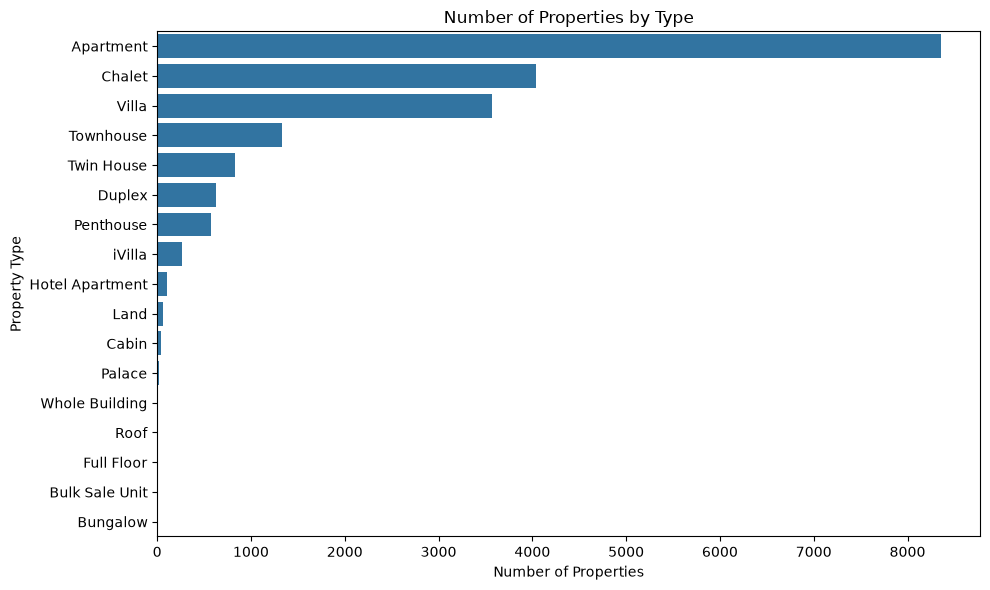

In [71]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="type",
    order=df["type"].value_counts().index
)

plt.title("Number of Properties by Type")
plt.xlabel("Number of Properties")
plt.ylabel("Property Type")

plt.tight_layout()
plt.show()

In [72]:
type_percentage = df["type"].value_counts(normalize=True) * 100
type_percentage.head(5)

type
Apartment     42.097042
Chalet        20.345644
Villa         17.987605
Townhouse      6.726457
Twin House     4.202146
Name: proportion, dtype: float64

In [73]:
type_percentage.head(3).sum()

np.float64(80.43029173174787)

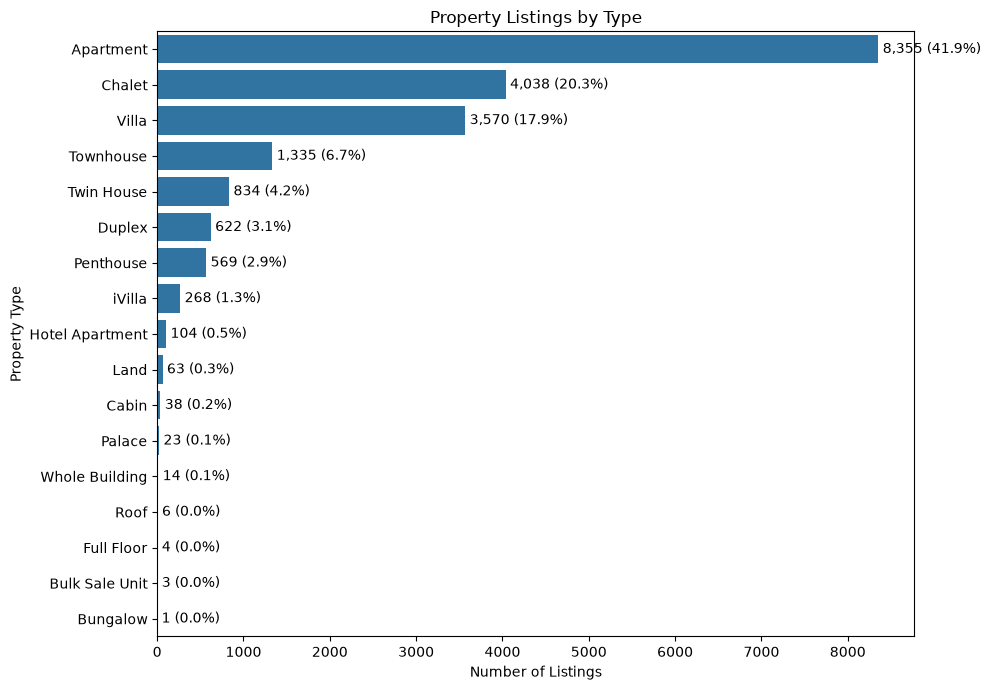

In [74]:
type_counts = df["type"].value_counts()
type_percentages = type_counts / len(df) * 100

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=type_counts.values,
    y=type_counts.index
)

plt.title("Property Listings by Type")
plt.xlabel("Number of Listings")
plt.ylabel("Property Type")

for i, (count, percentage) in enumerate(
    zip(type_counts.values, type_percentages.values)
):
    ax.text(
        count + 50,
        i,
        f"{count:,} ({percentage:.1f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

How are property prices distributed?

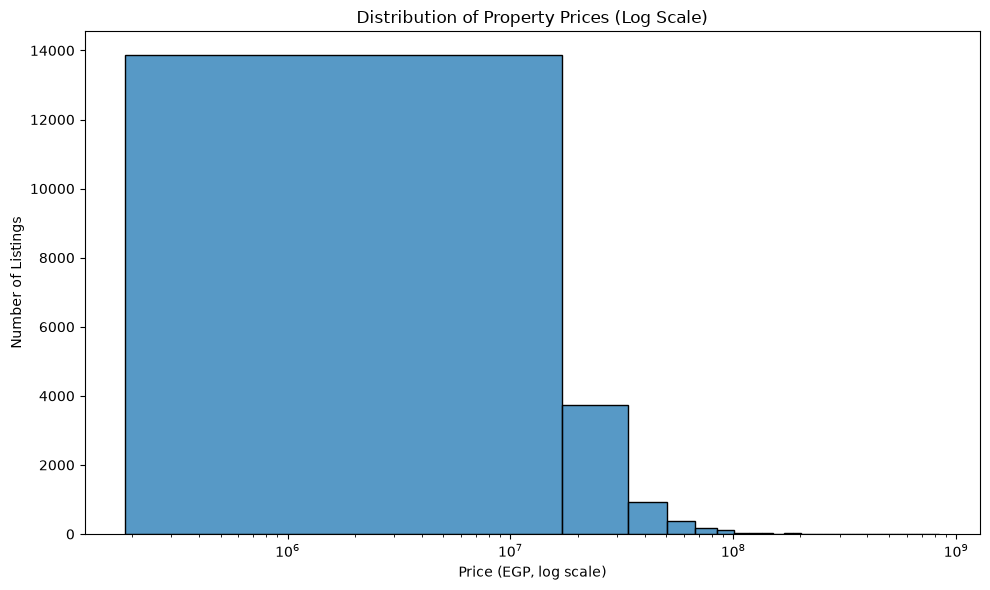

In [76]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="price_clean",
    bins=50
)

plt.xscale("log")

plt.title("Distribution of Property Prices (Log Scale)")
plt.xlabel("Price (EGP, log scale)")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

Property prices are strongly right-skewed, with most listings concentrated at lower price levels and a smaller number of high-value properties extending the distribution toward very high prices.

In [77]:
df["type"].value_counts()["Land"]

np.int64(63)

In [78]:
size_price_df = df[
    (df["type"] != "Land") &
    (df["size_sqm"].notna()) &
    (df["price_clean"].notna())
]

print(size_price_df.shape)

(19324, 18)


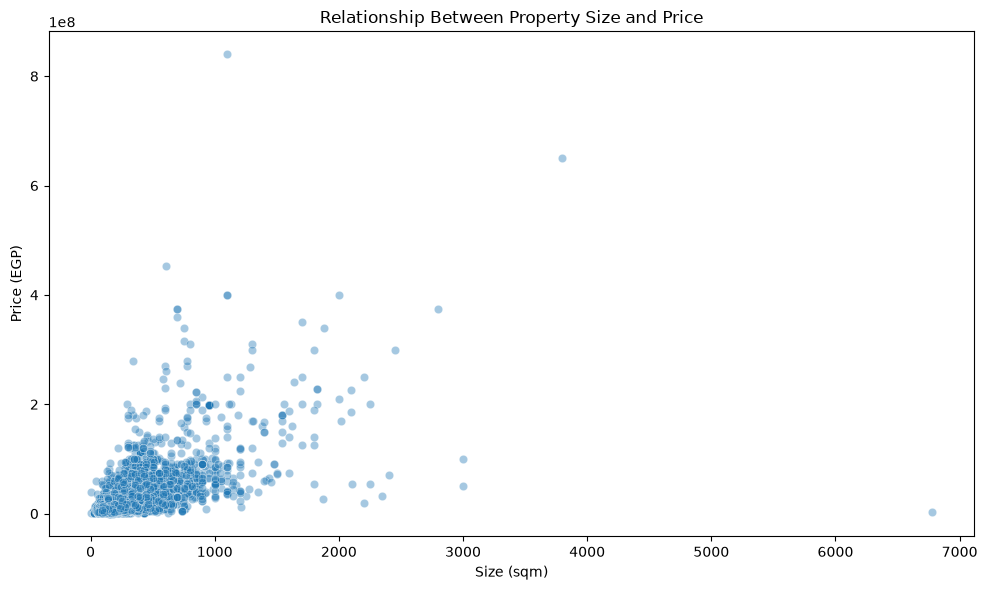

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_price_df,
    x="size_sqm",
    y="price_clean",
    alpha=0.4
)

plt.title("Relationship Between Property Size and Price")
plt.xlabel("Size (sqm)")
plt.ylabel("Price (EGP)")

plt.tight_layout()
plt.show()

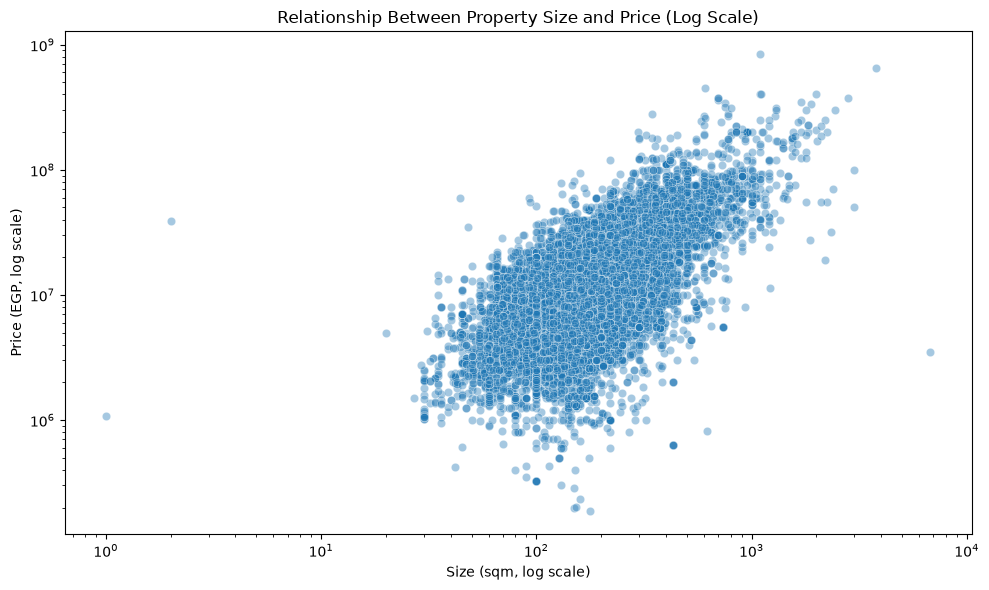

In [80]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_price_df,
    x="size_sqm",
    y="price_clean",
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title("Relationship Between Property Size and Price (Log Scale)")
plt.xlabel("Size (sqm, log scale)")
plt.ylabel("Price (EGP, log scale)")

plt.tight_layout()
plt.show()

In [81]:
size_price_df[["size_sqm", "price_clean"]].corr()

,size_sqm,price_clean
size_sqm,1.000000,0.650635
price_clean,0.650635,1.000000


In [82]:
size_price_df["size_sqm"].describe()

count    19324.000000
mean       209.968744
std        171.853358
min          1.000000
25%        126.000000
50%        170.000000
75%        237.000000
max       6779.000000
Name: size_sqm, dtype: float64

In [83]:
size_price_df["size_group"] = pd.cut(
    size_price_df["size_sqm"],
    bins=[0, 100, 150, 200, 300, 500, float("inf")],
    labels=[
        "≤100",
        "101–150",
        "151–200",
        "201–300",
        "301–500",
        ">500"
    ]
)

size_price_df["size_group"].value_counts().sort_index()

size_group
≤100       2612
101–150    5027
151–200    4824
201–300    4146
301–500    1979
>500        736
Name: count, dtype: int64

In [84]:
median_price_by_size = (
    size_price_df
    .groupby("size_group", observed=True)["price_clean"]
    .median()
)

median_price_by_size

size_group
≤100        5400000.0
101–150     8348920.0
151–200     9150000.0
201–300    15000000.0
301–500    27500000.0
>500       58000000.0
Name: price_clean, dtype: float64

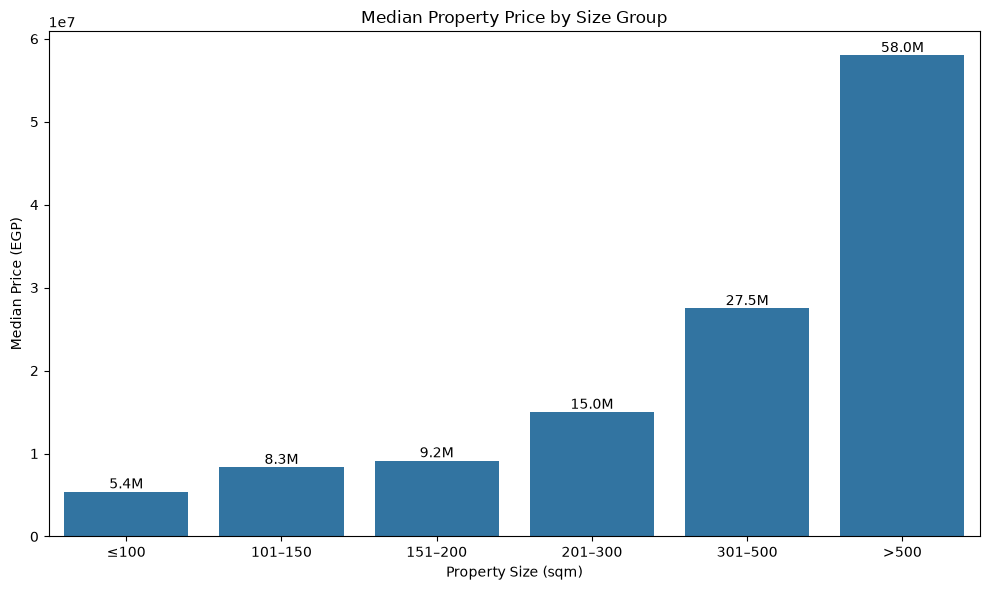

In [85]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=median_price_by_size.index,
    y=median_price_by_size.values
)

plt.title("Median Property Price by Size Group")
plt.xlabel("Property Size (sqm)")
plt.ylabel("Median Price (EGP)")

for i, value in enumerate(median_price_by_size.values):
    ax.text(
        i,
        value,
        f"{value / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Within this dataset, median property prices generally increase as property size increases, rising from 5.4M EGP for properties up to 100 sqm to 58M EGP for properties larger than 500 sqm.

In [86]:
median_price_by_type = (
    df.groupby("type")["price_clean"]
    .median()
    .sort_values(ascending=False)
)

median_price_by_type

type
Palace             199000000.0
Villa               28000000.0
Whole Building      27000000.0
Twin House          23000000.0
Townhouse           18000000.0
Hotel Apartment     13294000.0
Cabin               13000000.0
Penthouse           12500000.0
iVilla              12496000.0
Duplex              12300000.0
Chalet              10250000.0
Full Floor           7650000.0
Apartment            6750000.0
Bulk Sale Unit       6668000.0
Roof                 5700000.0
Bungalow             3600000.0
Land                 2500000.0
Name: price_clean, dtype: float64

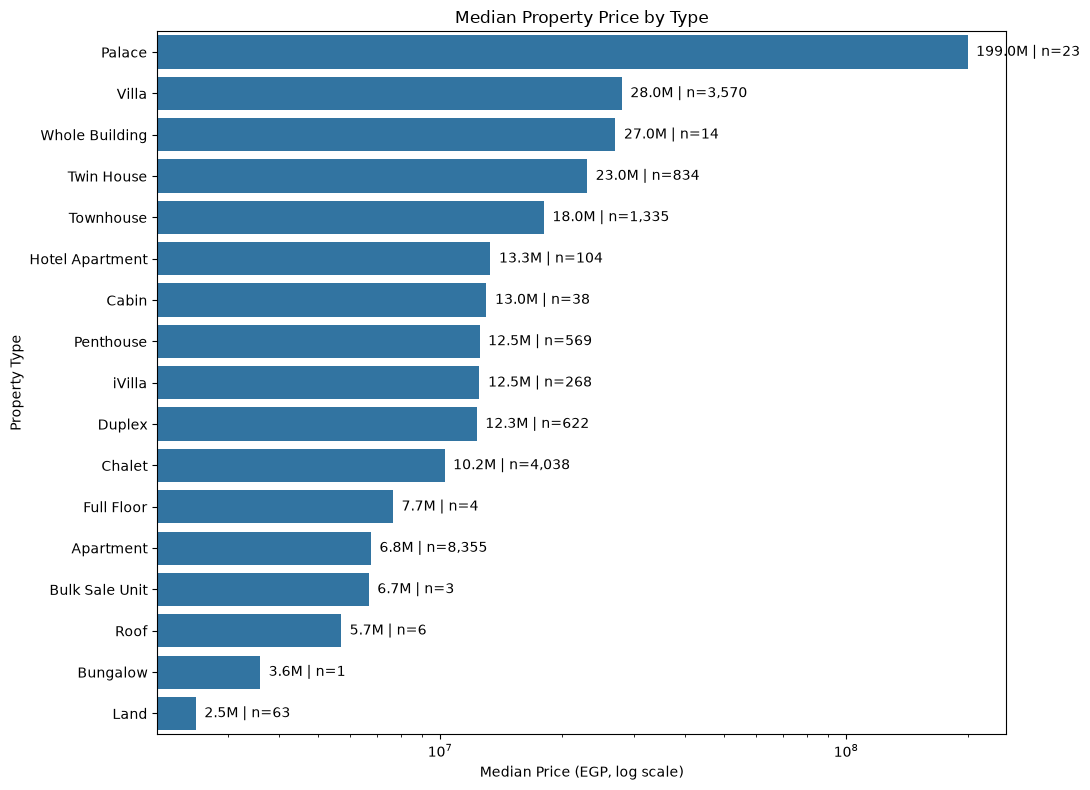

In [90]:
type_summary = type_summary.sort_values("Median_Price", ascending=False)

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=type_summary.reset_index(),
    x="Median_Price",
    y="type"
)

plt.xscale("log")

plt.title("Median Property Price by Type")
plt.xlabel("Median Price (EGP, log scale)")
plt.ylabel("Property Type")

for i, row in enumerate(type_summary.reset_index().itertuples()):
    ax.text(
        row.Median_Price * 1.05,
        i,
        f"{row.Median_Price / 1_000_000:.1f}M | n={row.Listings:,}",
        va="center"
    )

plt.tight_layout()
plt.show()